In [1]:
%matplotlib ipympl
from pylab import *
import control as ctrl

## Parametrisierung

### Aufgabe 5: Auslegung der Federung (Berechnung für k und d ist auskommentiert)

Der Dämpfungsgrad $D$ eines mechanischen Feder-Masse-Dämpfer Systems ist gegeben durch: <br>
$D = \frac{d}{2 \sqrt{m\cdot k}} \ = \frac{d \omega_n}{2k} \ = \frac{d }{2m \omega_n}$<br>
mit $\omega_n=\sqrt {\frac {k}{m}}$
    
- Nemen Sie die Masse als gegeben an mit 2 kg
- Legen Sie das System auf eine natürliche Resoanzfrequenz von 1 Hz aus
- Untersuchen Sie das Systemverhalten für $D=0.2$ (1. Reihe), $D=0.5$ (2. Reihe), $D=1.0$ (3. Reihe) und $D=1.5$ (4. Reihe)

> Typische Werte für Straßenfahrzeuge:<br>
> natürliche Resoanzfrequenz  $\omega_n  \approx 1\,\mathrm{Hz}$ <br>
> Dämpfungsgrad $0.2 < D < 0.4$
> <small>Fundamentals of vehicle dynamics: Thomas D. Gillespie, 2021</small>

In [2]:
m = 2  # Masse (kg)

wn = 2*pi * 1 # Natürliche Frequenz = 1 Hz
D = 0.2       # Dämpfungsgrad = 0.2

k = 800
#k = wn**2*m

d = 8
#d = D*2*m*wn

### Aufgabe 1: Modellierung der Bewegungsgleichung

$G(s) = \frac{y}{u} = \frac{sd + k}{s^2m + sd +k}$

In [3]:
s = ctrl.tf("s")  # Laplace-Variable definieren

# Feder-Masse-Dämpfer-Übertragungsfunktion erstellen:
G = (k + d*s) / (k + s*d + s**2 *m)

In [4]:
ctrl.dcgain(G)

np.float64(1.0)

### Aufgabe 2: Erzeugen Sie einen Eingang u, der das folgende Geländeprofil abbildet

0 m bis 1 m: gerade bei 0 cm<br>
1 m bis 2 m: konstant ansteigend von 0 cm auf 30 cm <br>
2 m bis 10 m: sprunghaft von 3 cm auf 0 cm und gerade weiter<br>
Bewegung mit konstanter Geschwindigkeit $v_0 = 30\,\mathrm{km/h}$



In [5]:
# Zeitachse für die Simulation definieren

dt = 0.001
v = 30/3.6
N = int(1/(dt*v)) # Werte pro Meter
u = hstack([
    zeros(N),                         # 1. Abschnitt (Gerade)
    linspace(0, 0.3, N),              # 2.Abschnitt (Rampe)
    zeros(8*N)                        # 3.Abschnitt
])

t = arange(len(u))*dt

(np.float64(-0.4954166666666668),
 np.float64(10.403750000000002),
 np.float64(-0.015),
 np.float64(0.315))

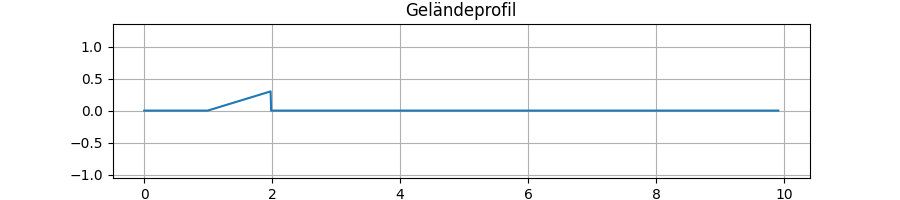

In [6]:
figure(figsize=(9,2)); title('Geländeprofil')
plot(t*v, u)
grid()
axis('equal')

### Aufgabe 3: Führen Sie die Simulation aus und visualisieren Sie das Ergebniss

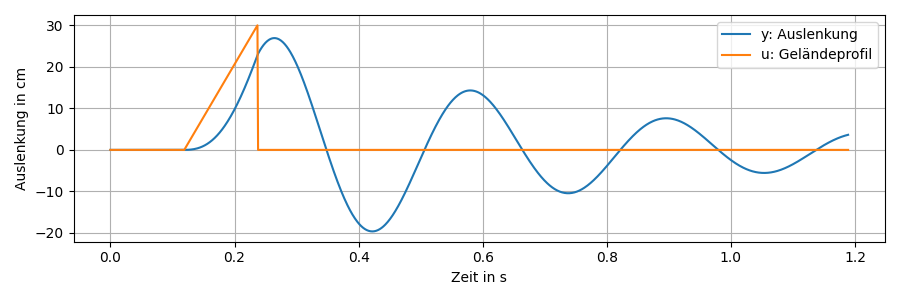

In [7]:
t, y = ctrl.forced_response(G, t, u)     # Systemantwort auf die Eingabe (Auslenkung) simulieren

figure(figsize=(9,3))
xlabel('Zeit in s');ylabel('Auslenkung in cm');
plot(t,y*100, label='y: Auslenkung');
plot(t,u*100, label='u: Geländeprofil');
legend();grid();tight_layout()

### Aufgabe 4:  Erstellen Sie das Bodediagram

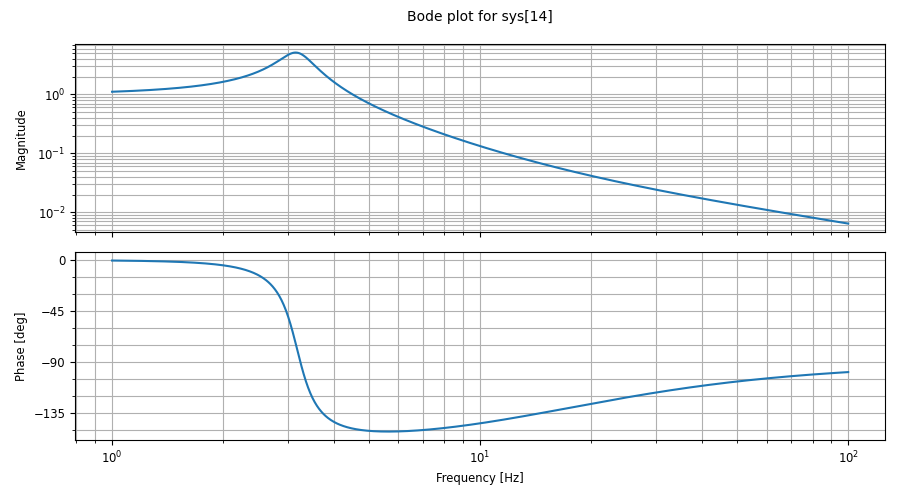

In [8]:
fig = figure(figsize=(9, 5))
_ = ctrl.bode_plot(G, dB=False, Hz=True)